# Phase 2 — Data Understanding

Companion to PLAN.md Phase 2. Acquires Food-101, runs EDA, audits quality, and locks train/val/test splits. See `docs/superpowers/specs/2026-05-07-phase2-data-understanding-design.md`.

## 0. Setup

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm


In [2]:
# Constants — change deliberately, every downstream phase depends on these.
SEED = 42
VAL_FRACTION = 0.10
PIXEL_STATS_SAMPLE = 2000
TINY_SHORT_SIDE = 256
PHASH_HAMMING_THRESHOLD = 5
PHASH_SCOPE = 'within_class'

FORCE_REBUILD = False        # re-compute cached EDA / audit cells
REGENERATE_SPLITS = False    # re-shuffle splits (DANGEROUS — invalidates downstream comparisons)

random.seed(SEED)
np.random.seed(SEED)


In [3]:
# Paths — relative to repo root. Notebook is launched from repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
DATA_ROOT = REPO_ROOT / 'data'
ARTIFACTS_DIR = REPO_ROOT / 'artifacts' / 'phase2'
FIGURES_DIR = REPO_ROOT / 'figures' / 'phase2'
SPLITS_DIR = REPO_ROOT / 'splits'

for d in [DATA_ROOT, ARTIFACTS_DIR, FIGURES_DIR, FIGURES_DIR / 'samples', SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EDA_STATS_PATH = ARTIFACTS_DIR / 'eda_stats.json'
BAD_FILES_PATH = ARTIFACTS_DIR / 'bad_files.json'
PHASH_CACHE_PATH = ARTIFACTS_DIR / 'phash_cache.parquet'
AUDIT_CACHE_PATH = ARTIFACTS_DIR / 'audit_cache.parquet'

print(f'REPO_ROOT = {REPO_ROOT}')


REPO_ROOT = /Users/nguyenviethung/swin-transformer-classification


In [4]:
def update_stats(key, value):
    """Read eda_stats.json, set one key, write back. Idempotent."""
    stats = {}
    if EDA_STATS_PATH.exists():
        stats = json.loads(EDA_STATS_PATH.read_text())
    stats[key] = value
    EDA_STATS_PATH.write_text(json.dumps(stats, indent=2, sort_keys=True))
    return stats

# Seed eda_stats.json with the constants we already know.
update_stats('split_seed', SEED)
update_stats('imagenet_stats', {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]})


{'imagenet_stats': {'mean': [0.485, 0.456, 0.406],
  'std': [0.229, 0.224, 0.225]},
 'split_seed': 42}

In [5]:
# ASSERT: setup primitives are defined and paths exist
for name in ['SEED', 'VAL_FRACTION', 'PIXEL_STATS_SAMPLE', 'TINY_SHORT_SIDE',
             'PHASH_HAMMING_THRESHOLD', 'PHASH_SCOPE', 'FORCE_REBUILD',
             'REGENERATE_SPLITS', 'DATA_ROOT', 'ARTIFACTS_DIR', 'FIGURES_DIR',
             'SPLITS_DIR', 'EDA_STATS_PATH', 'BAD_FILES_PATH', 'update_stats']:
    assert name in dir(), f'missing setup symbol: {name}'
for d in [DATA_ROOT, ARTIFACTS_DIR, FIGURES_DIR, SPLITS_DIR]:
    assert d.exists(), f'missing dir: {d}'
print('setup OK')

setup OK


## 1. Acquisition
Downloads Food-101 from the official ETH Zurich URL via torchvision. torchvision verifies the MD5 internally; if the checksum fails it raises.

In [6]:
from torchvision.datasets import Food101

# torchvision caches under DATA_ROOT/food-101/. download=True is a no-op if already present.
train_ds = Food101(root=str(DATA_ROOT), split='train', download=True)
test_ds  = Food101(root=str(DATA_ROOT), split='test',  download=True)

class_names = sorted(train_ds.classes)
label_to_idx = {c: i for i, c in enumerate(class_names)}


In [7]:
# Build flat path lists. Use repo-relative paths so split CSVs survive moving the data dir.
IMAGES_DIR = DATA_ROOT / 'food-101' / 'images'

def _read_meta(split):
    meta_file = DATA_ROOT / 'food-101' / 'meta' / f'{split}.txt'
    return [line.strip() for line in meta_file.read_text().splitlines() if line.strip()]

def _to_records(meta_lines):
    out = []
    for line in meta_lines:
        cls, fname = line.split('/')
        rel = f'data/food-101/images/{cls}/{fname}.jpg'
        out.append({'filepath': rel, 'label_name': cls, 'label_idx': label_to_idx[cls]})
    return out

train_files = _to_records(_read_meta('train'))
test_files  = _to_records(_read_meta('test'))

print(f'train={len(train_files):,}  test={len(test_files):,}  classes={len(class_names)}')
print('first 3 train paths:')
for r in train_files[:3]:
    print(' ', r['filepath'])


train=75,750  test=25,250  classes=101
first 3 train paths:
  data/food-101/images/apple_pie/1005649.jpg
  data/food-101/images/apple_pie/1014775.jpg
  data/food-101/images/apple_pie/1026328.jpg


In [8]:
# ASSERT: dataset acquired and inventoried
assert (DATA_ROOT / 'food-101' / 'images').exists(), 'food-101 images dir missing'
assert len(train_files) == 75750, f'expected 75750 train files, got {len(train_files)}'
assert len(test_files) == 25250, f'expected 25250 test files, got {len(test_files)}'
assert len(class_names) == 101, f'expected 101 classes, got {len(class_names)}'
print('acquisition OK')

acquisition OK


## 2. Class Distribution
Food-101 ships balanced (750 train / 250 test per class). We confirm rather than assume.

In [9]:
from collections import Counter

train_counts = Counter(r['label_name'] for r in train_files)
test_counts  = Counter(r['label_name'] for r in test_files)

balance_ok = (set(train_counts.values()) == {750}) and (set(test_counts.values()) == {250})
print(f'balanced exactly 750/250 per class: {balance_ok}')


balanced exactly 750/250 per class: True


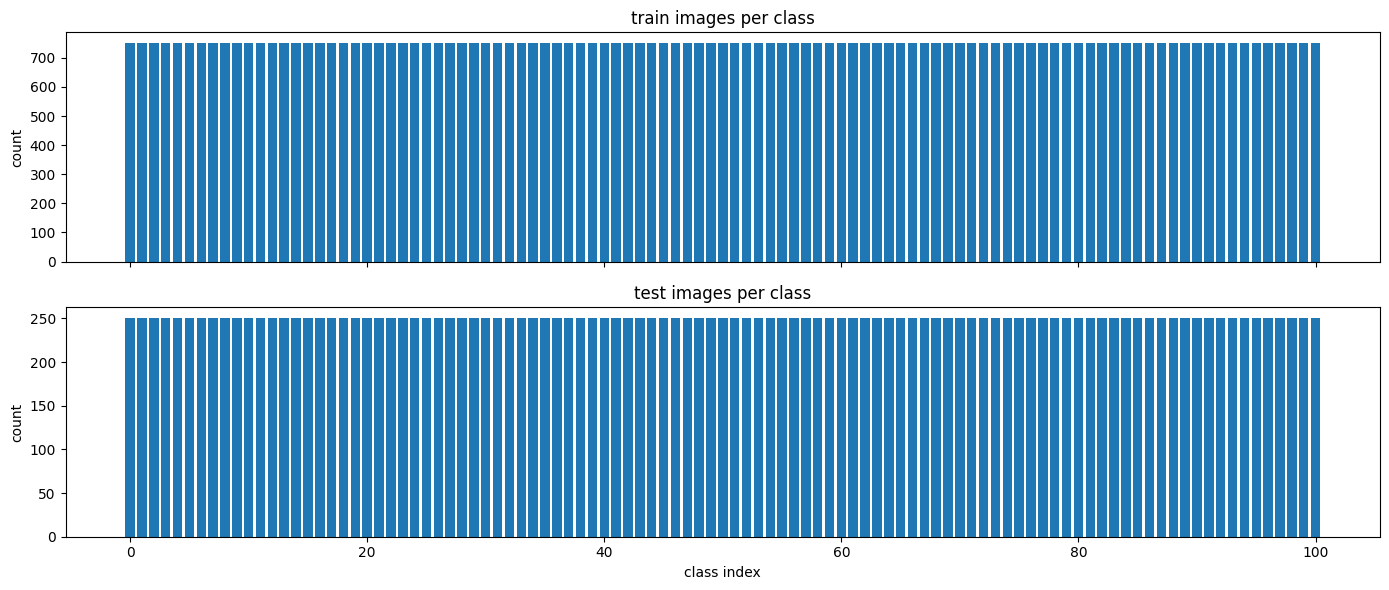

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ordered = sorted(class_names)
axes[0].bar(range(len(ordered)), [train_counts[c] for c in ordered])
axes[0].set_title('train images per class')
axes[0].set_ylabel('count')
axes[1].bar(range(len(ordered)), [test_counts[c] for c in ordered])
axes[1].set_title('test images per class')
axes[1].set_ylabel('count')
axes[1].set_xlabel('class index')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'class_dist.png', dpi=150)
plt.show()


In [11]:
update_stats('n_train', len(train_files))
update_stats('n_test', len(test_files))
update_stats('n_classes', len(class_names))
update_stats('class_counts', dict(train_counts))


{'imagenet_stats': {'mean': [0.485, 0.456, 0.406],
  'std': [0.229, 0.224, 0.225]},
 'n_classes': 101,
 'n_test': 25250,
 'n_train': 75750,
 'split_seed': 42,
 'class_counts': {'apple_pie': 750,
  'baby_back_ribs': 750,
  'baklava': 750,
  'beef_carpaccio': 750,
  'beef_tartare': 750,
  'beet_salad': 750,
  'beignets': 750,
  'bibimbap': 750,
  'bread_pudding': 750,
  'breakfast_burrito': 750,
  'bruschetta': 750,
  'caesar_salad': 750,
  'cannoli': 750,
  'caprese_salad': 750,
  'carrot_cake': 750,
  'ceviche': 750,
  'cheesecake': 750,
  'cheese_plate': 750,
  'chicken_curry': 750,
  'chicken_quesadilla': 750,
  'chicken_wings': 750,
  'chocolate_cake': 750,
  'chocolate_mousse': 750,
  'churros': 750,
  'clam_chowder': 750,
  'club_sandwich': 750,
  'crab_cakes': 750,
  'creme_brulee': 750,
  'croque_madame': 750,
  'cup_cakes': 750,
  'deviled_eggs': 750,
  'donuts': 750,
  'dumplings': 750,
  'edamame': 750,
  'eggs_benedict': 750,
  'escargots': 750,
  'falafel': 750,
  'filet_mi

In [12]:
# ASSERT: class distribution computed and persisted
import json as _json
stats = _json.loads(EDA_STATS_PATH.read_text())
assert 'class_counts' in stats and 'n_train' in stats and 'n_test' in stats and 'n_classes' in stats
assert stats['n_train'] == 75750
assert stats['n_test']  == 25250
assert stats['n_classes'] == 101
assert len(stats['class_counts']) == 101
assert (FIGURES_DIR / 'class_dist.png').exists()
print('class distribution OK')

class distribution OK
